# Notebook20 — Host Cell Engineering and CRISPR Intervention Simulation

Notebook20 introduces a cell-engineering recommendation layer to the CHO digital twin project.

Previous notebooks answered:

- Which clones should be advanced?
- Which clones should be tested next?
- How can the SDL loop improve clone selection?

Notebook20 asks a new question:

**How can we improve promising but imperfect clones through biological intervention?**

This notebook does not claim to predict exact CRISPR outcomes.  
Instead, it uses conservative, literature-informed assumptions to simulate directional intervention effects.

The goal is to connect clone bottlenecks to plausible host-cell engineering strategies.

## Section 1 — Load Notebook18 Candidate Dashboard

Notebook18 generated the executive clone screening dashboard.

This file contains clone-level scores for:

- productivity
- quality
- stability
- omics
- RL robustness
- overall score
- decision category

Notebook20 uses this table as the starting population for engineering analysis.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[0]

dashboard = pd.read_csv(
    ROOT / "data/synthetic/digital_twin/notebook18_candidate_dashboard_5000_legacy.csv"
)

print("Dashboard shape:", dashboard.shape)
display(dashboard.head())

Dashboard shape: (94, 8)


,clone_id,overall_score,score_productivity,score_quality,score_stability,omics_score,rl_robustness_score,decision
0,CLONE_4625,59.323924,100.000000,69.850174,83.065313,17.302240,58.422895,Advance
1,CLONE_4878,51.055084,79.679015,66.381308,69.204240,11.833808,63.761372,Advance
2,CLONE_3895,42.862936,1.170372,98.964170,82.267468,28.517580,79.479074,Advance
3,CLONE_3895,42.631425,1.170372,98.607662,82.267468,28.517580,78.902602,Advance with Monitoring
4,CLONE_3895,42.595722,1.170372,98.964170,82.267468,26.736152,79.479074,Advance with Monitoring


## Section 2 — Select Engineering Population

Engineering resources are limited.

Therefore, we focus on clones that still have development value.

These include:

- Advance clones
- Advance with Monitoring clones
- Engineer clones

Terminate clones are excluded from this first intervention screen.

In [2]:
engineering_pool = dashboard[
    dashboard["decision"].isin(
        ["Advance", "Advance with Monitoring", "Engineer"]
    )
].copy()

print("Engineering pool size:", len(engineering_pool))
display(engineering_pool.head())

Engineering pool size: 36


,clone_id,overall_score,score_productivity,score_quality,score_stability,omics_score,rl_robustness_score,decision
0,CLONE_4625,59.323924,100.000000,69.850174,83.065313,17.302240,58.422895,Advance
1,CLONE_4878,51.055084,79.679015,66.381308,69.204240,11.833808,63.761372,Advance
2,CLONE_3895,42.862936,1.170372,98.964170,82.267468,28.517580,79.479074,Advance
3,CLONE_3895,42.631425,1.170372,98.607662,82.267468,28.517580,78.902602,Advance with Monitoring
4,CLONE_3895,42.595722,1.170372,98.964170,82.267468,26.736152,79.479074,Advance with Monitoring


## Section 3 — Define Intervention Knowledge Base

This section defines conservative synthetic intervention effects.

Each intervention represents a plausible host-cell engineering strategy.

The values are simulation assumptions, not universal biological constants.

Positive values improve a score.  
Negative values reduce burden or risk.

In [3]:
interventions = {
    "XBP1s_secretory_support": {
        "productivity": 0.06,
        "quality": 0.03,
        "burden": -0.10,
        "risk": -0.05,
    },
    "PDI_folding_support": {
        "productivity": 0.03,
        "quality": 0.08,
        "burden": -0.05,
        "risk": -0.03,
    },
    "B4GALT1_glycoengineering": {
        "quality": 0.10,
    },
    "ST6GAL1_sialylation_support": {
        "quality": 0.08,
    },
    "LDHA_overflow_reduction": {
        "burden": -0.12,
        "productivity": -0.02,
    },
    "BCL2_survival_support": {
        "stability": 0.08,
        "risk": -0.08,
    },
}

interventions

{'XBP1s_secretory_support': {'productivity': 0.06,
  'quality': 0.03,
  'burden': -0.1,
  'risk': -0.05},
 'PDI_folding_support': {'productivity': 0.03,
  'quality': 0.08,
  'burden': -0.05,
  'risk': -0.03},
 'B4GALT1_glycoengineering': {'quality': 0.1},
 'ST6GAL1_sialylation_support': {'quality': 0.08},
 'LDHA_overflow_reduction': {'burden': -0.12, 'productivity': -0.02},
 'BCL2_survival_support': {'stability': 0.08, 'risk': -0.08}}

## Section 4 — Detect Clone Bottlenecks

Each clone is evaluated to identify its weakest biological dimension.

The lowest score is treated as the dominant bottleneck.

Possible bottlenecks include:

- productivity
- quality
- stability
- omics support
- RL controllability

In [4]:
def detect_bottleneck(row):
    score_map = {
        "productivity": row["score_productivity"],
        "quality": row["score_quality"],
        "stability": row["score_stability"],
        "omics": row["omics_score"],
        "rl_controllability": row["rl_robustness_score"],
    }
    return min(score_map, key=score_map.get)


engineering_pool["bottleneck"] = engineering_pool.apply(
    detect_bottleneck,
    axis=1,
)

display(
    engineering_pool[
        ["clone_id", "overall_score", "bottleneck"]
    ].head()
)

,clone_id,overall_score,bottleneck
0,CLONE_4625,59.323924,omics
1,CLONE_4878,51.055084,omics
2,CLONE_3895,42.862936,productivity
3,CLONE_3895,42.631425,productivity
4,CLONE_3895,42.595722,productivity


## Section 5 — Map Bottlenecks to Interventions

Each bottleneck is mapped to a biologically plausible intervention.

This creates the first version of the engineering recommendation engine.

In [5]:
bottleneck_to_intervention = {
    "productivity": "XBP1s_secretory_support",
    "quality": "B4GALT1_glycoengineering",
    "stability": "BCL2_survival_support",
    "omics": "PDI_folding_support",
    "rl_controllability": "XBP1s_secretory_support",
}

engineering_pool["recommended_intervention"] = (
    engineering_pool["bottleneck"]
    .map(bottleneck_to_intervention)
)

display(
    engineering_pool[
        [
            "clone_id",
            "bottleneck",
            "recommended_intervention",
        ]
    ].head()
)

,clone_id,bottleneck,recommended_intervention
0,CLONE_4625,omics,PDI_folding_support
1,CLONE_4878,omics,PDI_folding_support
2,CLONE_3895,productivity,XBP1s_secretory_support
3,CLONE_3895,productivity,XBP1s_secretory_support
4,CLONE_3895,productivity,XBP1s_secretory_support


## Section 6 — Simulate Intervention Effects

The recommended intervention is applied to each clone.

A conservative improvement is added to the clone score.

Small biological noise is included to represent uncertainty in engineering response.

In [6]:
np.random.seed(42)

def simulate_intervention(row):
    intervention = row["recommended_intervention"]
    effects = interventions[intervention]

    gain = 0

    if "productivity" in effects:
        gain += effects["productivity"] * 100

    if "quality" in effects:
        gain += effects["quality"] * 100

    if "stability" in effects:
        gain += effects["stability"] * 100

    if "burden" in effects:
        gain += abs(effects["burden"]) * 50

    if "risk" in effects:
        gain += abs(effects["risk"]) * 50

    noise = np.random.normal(0, 2)

    return row["overall_score"] + gain + noise


engineering_pool["post_engineering_score"] = (
    engineering_pool.apply(simulate_intervention, axis=1)
)

engineering_pool["engineering_gain"] = (
    engineering_pool["post_engineering_score"]
    - engineering_pool["overall_score"]
)

display(
    engineering_pool[
        [
            "clone_id",
            "overall_score",
            "post_engineering_score",
            "engineering_gain",
        ]
    ].head()
)

,clone_id,overall_score,post_engineering_score,engineering_gain
0,CLONE_4625,59.323924,75.317352,15.993428
1,CLONE_4878,51.055084,65.778556,14.723471
2,CLONE_3895,42.862936,60.658313,17.795377
3,CLONE_3895,42.631425,62.177485,19.546060
4,CLONE_3895,42.595722,58.627415,16.031693


## Section 7 — Rank Engineering Opportunities

Engineering gain estimates how much improvement is expected after intervention.

Higher gain indicates a stronger engineering opportunity.

In [7]:
opportunities = (
    engineering_pool
    .sort_values("engineering_gain", ascending=False)
    .copy()
)

display(
    opportunities[
        [
            "clone_id",
            "decision",
            "bottleneck",
            "recommended_intervention",
            "overall_score",
            "post_engineering_score",
            "engineering_gain",
        ]
    ].head(20)
)

,clone_id,decision,bottleneck,recommended_intervention,overall_score,post_engineering_score,engineering_gain
31,CLONE_1091,Engineer,productivity,XBP1s_secretory_support,36.186520,56.391077,20.204556
6,CLONE_0080,Advance with Monitoring,productivity,XBP1s_secretory_support,42.126019,61.784445,19.658426
3,CLONE_3895,Advance with Monitoring,productivity,XBP1s_secretory_support,42.631425,62.177485,19.546060
20,CLONE_4425,Engineer,productivity,XBP1s_secretory_support,37.880277,57.311574,19.431298
34,CLONE_3546,Engineer,productivity,XBP1s_secretory_support,36.075012,54.220102,18.145090
7,CLONE_1633,Advance with Monitoring,productivity,XBP1s_secretory_support,40.895251,58.930120,18.034869
2,CLONE_3895,Advance,productivity,XBP1s_secretory_support,42.862936,60.658313,17.795377
9,CLONE_3269,Advance with Monitoring,productivity,XBP1s_secretory_support,39.714494,57.299615,17.585120
27,CLONE_2723,Engineer,productivity,XBP1s_secretory_support,36.587846,53.839242,17.251396
17,CLONE_0894,Engineer,productivity,XBP1s_secretory_support,38.457279,55.585774,17.128495


## Section 8 — Visualize Engineering Impact

This plot compares clone scores before and after simulated engineering.

Each point represents one clone.

The diagonal line means no improvement.

Points above the line improved after intervention.

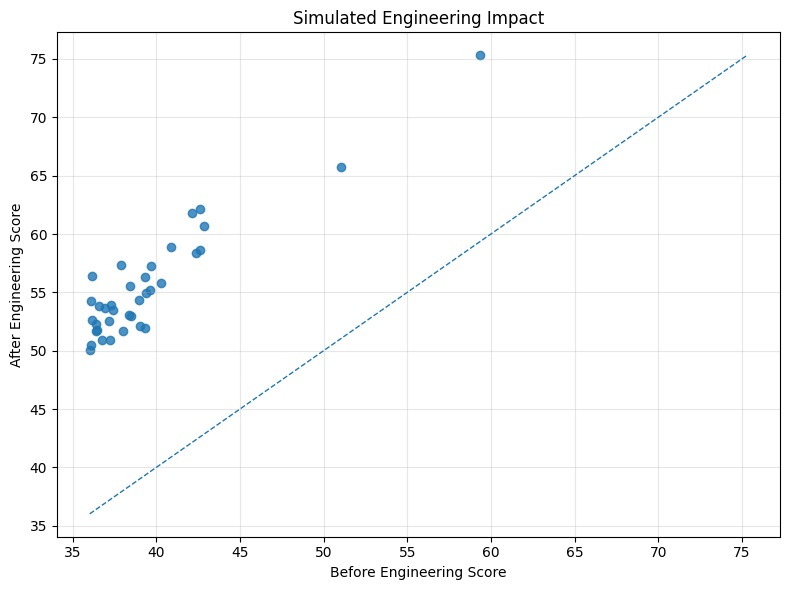

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(
    engineering_pool["overall_score"],
    engineering_pool["post_engineering_score"],
    alpha=0.8,
)

min_score = min(
    engineering_pool["overall_score"].min(),
    engineering_pool["post_engineering_score"].min(),
)

max_score = max(
    engineering_pool["overall_score"].max(),
    engineering_pool["post_engineering_score"].max(),
)

plt.plot(
    [min_score, max_score],
    [min_score, max_score],
    linestyle="--",
    linewidth=1,
)

plt.xlabel("Before Engineering Score")
plt.ylabel("After Engineering Score")
plt.title("Simulated Engineering Impact")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 9 — Intervention Portfolio Analysis

This section counts how often each intervention is recommended.

The result shows which biological bottlenecks dominate the clone population.

recommended_intervention
XBP1s_secretory_support    34
PDI_folding_support         2
Name: count, dtype: int64

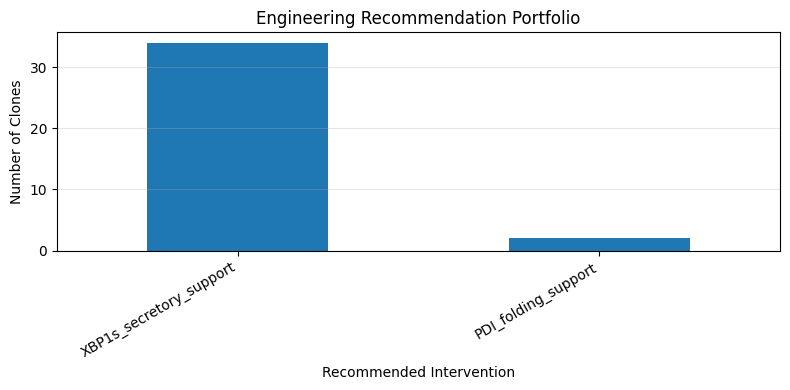

In [9]:
portfolio = (
    engineering_pool["recommended_intervention"]
    .value_counts()
)

display(portfolio)

portfolio.plot.bar(figsize=(8, 4))

plt.title("Engineering Recommendation Portfolio")
plt.xlabel("Recommended Intervention")
plt.ylabel("Number of Clones")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Section 10 — CRISPR Opportunity Summary

This table translates intervention names into possible biological targets.

These are design hypotheses for future experimental validation.

In [10]:
crispr_summary = pd.DataFrame(
    {
        "intervention": [
            "XBP1s_secretory_support",
            "PDI_folding_support",
            "B4GALT1_glycoengineering",
            "ST6GAL1_sialylation_support",
            "LDHA_overflow_reduction",
            "BCL2_survival_support",
        ],
        "possible_target": [
            "XBP1",
            "P4HB / PDI pathway",
            "B4GALT1",
            "ST6GAL1",
            "LDHA",
            "BCL2",
        ],
        "biological_goal": [
            "Improve secretory capacity and reduce ER stress",
            "Improve protein folding and proteostasis",
            "Increase galactosylation potential",
            "Increase sialylation potential",
            "Reduce lactate / overflow burden",
            "Improve survival and stress resistance",
        ],
    }
)

display(crispr_summary)

,intervention,possible_target,biological_goal
0,XBP1s_secretory_support,XBP1,Improve secretory capacity and reduce ER stress
1,PDI_folding_support,P4HB / PDI pathway,Improve protein folding and proteostasis
2,B4GALT1_glycoengineering,B4GALT1,Increase galactosylation potential
3,ST6GAL1_sialylation_support,ST6GAL1,Increase sialylation potential
4,LDHA_overflow_reduction,LDHA,Reduce lactate / overflow burden
5,BCL2_survival_support,BCL2,Improve survival and stress resistance


## Section 11 — Cell Engineering Scorecard

This scorecard summarizes the overall engineering opportunity.

It provides a quick portfolio-level view for decision makers.

In [11]:
scorecard = pd.DataFrame(
    {
        "metric": [
            "engineering_candidates",
            "mean_engineering_gain",
            "best_engineering_gain",
            "unique_interventions",
        ],
        "value": [
            len(engineering_pool),
            round(engineering_pool["engineering_gain"].mean(), 2),
            round(engineering_pool["engineering_gain"].max(), 2),
            engineering_pool["recommended_intervention"].nunique(),
        ],
    }
)

display(scorecard)

,metric,value
0,engineering_candidates,36.00
1,mean_engineering_gain,16.09
2,best_engineering_gain,20.20
3,unique_interventions,2.00


## Section 12 — Export Intervention Outputs

The engineering recommendation datasets are exported for future notebooks.

These files can support:

- CRISPR prioritization
- SDL intervention planning
- host-cell engineering strategy design

In [12]:
out_dir = ROOT / "data/synthetic/digital_twin"

engineering_pool.to_csv(
    out_dir / "notebook20_engineering_recommendations_5000_legacy.csv",
    index=False,
)

opportunities.to_csv(
    out_dir / "notebook20_ranked_engineering_opportunities_5000_legacy.csv",
    index=False,
)

scorecard.to_csv(
    out_dir / "notebook20_engineering_scorecard_5000_legacy.csv",
    index=False,
)

print("Notebook20 exports saved.")

Notebook20 exports saved.


# Final Summary

Notebook20 introduced a host-cell engineering layer to the CHO digital twin platform.

The notebook performed the following steps:

1. Loaded clone candidates from Notebook18
2. Selected clones suitable for engineering analysis
3. Detected dominant clone bottlenecks
4. Matched bottlenecks to plausible interventions
5. Simulated conservative intervention effects
6. Estimated engineering gain
7. Ranked engineering opportunities
8. Summarized possible CRISPR targets
9. Exported intervention datasets

This notebook extends the project from clone selection into clone improvement.

The platform can now support:

Prediction → Selection → SDL Experiment Planning → Cell Engineering Recommendation

Notebook20 is not intended to claim exact CRISPR outcomes.

Instead, it demonstrates how a digital twin can generate biologically grounded intervention hypotheses.

# References

## CHO Cell Engineering

Wurm FM.  
Production of recombinant protein therapeutics in cultivated mammalian cells.  
Nature Biotechnology, 2004.  
DOI: 10.1038/nbt1026

Kim JY, Kim YG, Lee GM.  
CHO cells in biotechnology for production of recombinant proteins.  
Current Opinion in Biotechnology, 2012.  
DOI: 10.1016/j.copbio.2011.10.002

## Secretory Pathway and ER Stress Engineering

Ku SCY, Ng DTW, Yap MGS, Chao SH.  
Effects of overexpression of XBP-1 on recombinant protein production in CHO and NS0 myeloma cells.  
Biotechnology and Bioengineering, 2008.

## Glycoengineering

Amann T, Hansen AH, Kol S, et al.  
Glyco-engineered CHO cell lines producing alpha-1-antitrypsin and C1 esterase inhibitor with fully humanized N-glycosylation profiles.  
Metabolic Engineering, 2019.

## Cell Survival and Apoptosis Engineering

Fussenegger M, Bailey JE.  
Molecular regulation of cell-cycle progression and apoptosis in mammalian cells: implications for biotechnology.  
Biotechnology Progress, 1998.

## Digital Twins and SDL

Narciso-da-Rocha C, et al.  
Digital twins in biopharmaceutical manufacturing.  
Biotechnology Advances, 2024.  
DOI: 10.1016/j.biotechadv.2024.108388

FDA.  
PAT — A Framework for Innovative Pharmaceutical Development, Manufacturing, and Quality Assurance.  
2004.